In [24]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

In [25]:
#reading the dataset

df = pd.read_csv("cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [27]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [28]:
df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64

In [29]:
#checking the defaulted status of the people who did not report their income

# Default rate among people who did NOT report income (missing MonthlyIncome)
df[df['MonthlyIncome'].isnull()]['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    94.386331
1     5.613669
Name: proportion, dtype: float64

In [30]:
#handling the missing values in monthly income and numberOfDependents

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].mode()[0])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         150000 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  NumberOfDep

In [31]:
#drop unnamed column (of no use anyway)
df = df.drop('Unnamed: 0', axis=1)

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

#train-test-split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(y_val.value_counts(normalize=True))

SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


In [32]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

log_reg.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [33]:
y_pred = log_reg.predict(X_val_scaled)

accuracy = accuracy_score(y_pred, y_val)
print(accuracy)

print(classification_report(y_val, y_pred))


0.7762666666666667
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     27995
           1       0.18      0.67      0.29      2005

    accuracy                           0.78     30000
   macro avg       0.58      0.73      0.58     30000
weighted avg       0.92      0.78      0.83     30000



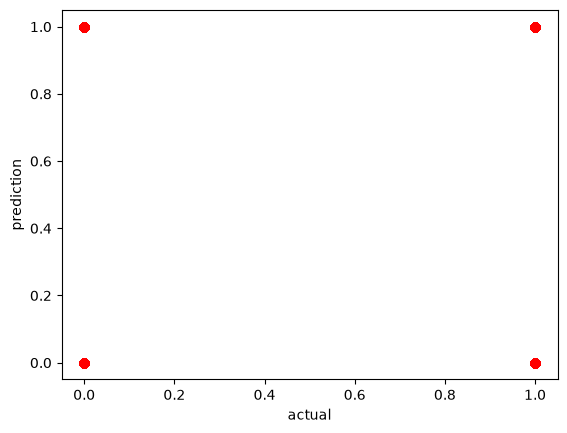

In [34]:
plt.scatter(y_val, y_pred, c='r')
plt.xlabel('actual')
plt.ylabel('prediction')
plt.show()

In [35]:
y_proba_log = log_reg.predict_proba(X_val_scaled)[:, 1]
print("Logistic Regression ROC-AUC:", roc_auc_score(y_val, y_proba_log))

Logistic Regression ROC-AUC: 0.8021466604964638


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)
y_proba_rf = rf.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_rf))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96     27995
           1       0.42      0.36      0.39      2005

    accuracy                           0.92     30000
   macro avg       0.69      0.66      0.68     30000
weighted avg       0.92      0.92      0.92     30000

ROC-AUC: 0.847694061862668


In [37]:
y_pred_thresh = (y_proba_rf > 0.3).astype(int)
print(classification_report(y_val, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94     27995
           1       0.31      0.58      0.41      2005

    accuracy                           0.89     30000
   macro avg       0.64      0.74      0.67     30000
weighted avg       0.92      0.89      0.90     30000



In [38]:
y_pred_thresh25 = (y_proba_rf > 0.25).astype(int)
print(classification_report(y_val, y_pred_thresh25))

              precision    recall  f1-score   support

           0       0.97      0.88      0.93     27995
           1       0.28      0.63      0.39      2005

    accuracy                           0.87     30000
   macro avg       0.63      0.76      0.66     30000
weighted avg       0.92      0.87      0.89     30000



In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print(rf_search.best_params_)
print(rf_search.best_score_)

{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
0.8602827323600125


In [40]:
best_rf = rf_search.best_estimator_
y_proba_best = best_rf.predict_proba(X_val)[:, 1]

print("ROC-AUC:", roc_auc_score(y_val, y_proba_best))

y_pred_best = (y_proba_best > 0.3).astype(int)
print(classification_report(y_val, y_pred_best))

ROC-AUC: 0.8665867479898219
              precision    recall  f1-score   support

           0       0.99      0.63      0.77     27995
           1       0.15      0.89      0.25      2005

    accuracy                           0.64     30000
   macro avg       0.57      0.76      0.51     30000
weighted avg       0.93      0.64      0.73     30000



In [41]:
for t in [0.6, 0.7]:
    pred = (y_proba_best > t).astype(int)
    print(f"Threshold {t}:")
    print(classification_report(y_val, pred))
    print("---")

Threshold 0.6:
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     27995
           1       0.30      0.65      0.41      2005

    accuracy                           0.88     30000
   macro avg       0.64      0.77      0.67     30000
weighted avg       0.93      0.88      0.90     30000

---
Threshold 0.7:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     27995
           1       0.37      0.54      0.44      2005

    accuracy                           0.91     30000
   macro avg       0.67      0.74      0.69     30000
weighted avg       0.93      0.91      0.91     30000

---


In [42]:
for t in [0.8, 0.85]:
    pred = (y_proba_best > t).astype(int)
    print(f"Threshold {t}:")
    print(classification_report(y_val, pred))
    print("---")

Threshold 0.8:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96     27995
           1       0.45      0.41      0.43      2005

    accuracy                           0.93     30000
   macro avg       0.70      0.69      0.70     30000
weighted avg       0.92      0.93      0.93     30000

---
Threshold 0.85:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     27995
           1       0.50      0.32      0.39      2005

    accuracy                           0.93     30000
   macro avg       0.73      0.65      0.68     30000
weighted avg       0.92      0.93      0.93     30000

---


In [43]:
# Model: tuned Random Forest (n_estimators=200, max_depth=10, min_samples_split=10, min_samples_leaf=4, max_features='sqrt')
# Threshold: 0.75
# ROC-AUC: 0.867

#final params and hyperparams

In [44]:
print(rf.feature_names_in_)

['RevolvingUtilizationOfUnsecuredLines' 'age'
 'NumberOfTime30-59DaysPastDueNotWorse' 'DebtRatio' 'MonthlyIncome'
 'NumberOfOpenCreditLinesAndLoans' 'NumberOfTimes90DaysLate'
 'NumberRealEstateLoansOrLines' 'NumberOfTime60-89DaysPastDueNotWorse'
 'NumberOfDependents']


In [46]:
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance for XGBoost (ratio of negative to positive class)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_val)[:, 1]
print("ROC-AUC:", roc_auc_score(y_val, y_proba_xgb))

y_pred_xgb = (y_proba_xgb > 0.5).astype(int)
print(classification_report(y_val, y_pred_xgb))

ROC-AUC: 0.8656934641428222
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.77      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.81      0.85     30000



In [49]:
for t in [0.8]:
    pred = (y_proba_xgb > t).astype(int)
    print(f"Threshold {t}:")
    print(classification_report(y_val, pred))
    print("---")

Threshold 0.8:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     27995
           1       0.42      0.46      0.44      2005

    accuracy                           0.92     30000
   macro avg       0.69      0.71      0.70     30000
weighted avg       0.93      0.92      0.92     30000

---


In [50]:
import joblib
joblib.dump(xgb, 'loan_default_model.joblib')

['loan_default_model.joblib']